# PBL 9: Propensity Score Matching for Oral Cancer Treatment

## Problem overview
### Scenario:
Trying to find whether receiving treatment is associated with better survival in oral cancer patients.
- The data is observational: treatment was not randomized, so patient characteristics can line up with both who gets treated and who survives.

### Dataset
provided in class: oral_cancer_final.csv

includes:
- demographics,
- clinical variables (e.g. tumour size, stage),
- risk factors and history,
- a treatment indicator (Treatment, 0 or 1)
-  a binary outcome (Survival, 0 or 1).

A raw comparison of survival by treatment group can be biased by confounding. Propensity score matching adjusts for measured confounders so treated and untreated groups are more comparable before comparing outcomes.

### Learning objectives

- Profile an observational dataset and flag issues that affect the analysis.
- Choose confounders using a model for treatment plus short clinical justification.
- Fit propensity scores, check overlap, and run 1:1 nearest-neighbour matching with a caliper.
- Compute average treatment effects (ATE) on survival before and after matching and compare them.
- Show results in tables and plots and state limitations in plain language.

## Task 1: Confounders, propensity score matching, and treatment effects

###Overview
When using observational oral cancer data, because treatment may not be randomized, a simple difference in Survival between treated and untreated patients can be confounded.

- In this task I load data, compare groups before matching, choose confounders, estimate propensity scores, match treated to control patients, then compare average treatment effect (ATE) on survival before and after matching.

- Data: provided in class: oral_cancer_final.csv  
  - Main columns:
    - Treatment (0/1)
    - Survival (0/1)



### Step 1: load and inspect data

In [1]:
import pandas as pd

#load data
df = pd.read_csv('oral_cancer_final.csv')

In [2]:
#inspect
print(df.head())
print(df.info())
print(df.shape)
print(df.isnull().sum())
print(df.describe(include='all'))


    Age Gender  Tobacco Use  Alcohol Consumption  HPV Infection  \
0  64.0   Male            1                    1              1   
1  57.0   Male            1                    1              0   
2  57.0   Male            1                    0              1   
3  57.0   Male            0                    0              0   
4  77.0   Male            1                    1              0   

   Betel Quid Use  Chronic Sun Exposure Poor Oral Hygiene  \
0               0                     1               Yes   
1               1                     1               Yes   
2               0                     1                No   
3               0                     0               Yes   
4               1                     0                No   

  Family History of Cancer  Compromised Immune System  ...  \
0                       No                          0  ...   
1                       No                          0  ...   
2                       No                  

In [3]:
#class distribution
print(df['Treatment'].value_counts())
print(df['Survival'].value_counts())

Treatment
1    3382
0     853
Name: count, dtype: int64
Survival
1.0    2801
0.0    1434
Name: count, dtype: int64


- baseline variables : age, gender, risk/confounding factors (tobacco use, alcohol use, hpv infection, berel quid use, sun exposure, oral hygeine), medical history (family history of cancer, immunocompromised), symptoms (difficulty swallowing, white/red patches), severity (tumour size, cancer stage)

- casual path variables : chemo, radiation, surgery, targeted therapty

- survival must not be included in the treatment model as it is an outcome that occurs after treatment, if it was included there would be data leakage and the model accuracy would be misleading

- there are no missing values in the data but certain values are stored as text (like poor oral hygiene yes/no) which will have to be encoded - balance must also be checked in the variables



### Compare treated vs untreated (before matching)

- grouping by Treatment and comparing distributions of important variables
- using tables and plots so baseline imbalance is easy to see


In [14]:
print(df.groupby('Treatment')['Age'].describe())
print(df.groupby('Treatment')['Tumor Size (cm)'].describe())
print(df.groupby('Treatment')[ 'Cancer Stage'].describe())


            count       mean        std   min   25%   50%   75%   max
Treatment                                                            
0           853.0  54.540445  10.094963  18.0  48.0  55.0  61.0  83.0
1          3382.0  59.476345  10.138083  22.0  53.0  59.0  67.0  93.0
            count      mean       std       min       25%       50%       75%  \
Treatment                                                                       
0           853.0  3.522543  1.435137  1.002563  2.319337  3.505322  4.794649   
1          3382.0  4.978171  1.512578  1.308577  3.742839  4.938214  6.217718   

                max  
Treatment            
0          5.998217  
1          8.601804  
            count      mean       std  min  25%  50%  75%  max
Treatment                                                     
0           853.0  2.211020  1.033487  1.0  1.0  2.0  3.0  4.0
1          3382.0  2.255766  1.034993  1.0  1.0  2.0  3.0  4.0


In [5]:
pd.crosstab(df['Treatment'], df['Gender'], normalize='index')

Gender,Female,Male
Treatment,,
0,0.509965,0.490035
1,0.204021,0.795979


In [10]:
pd.crosstab(df['Treatment'], df['Alcohol Consumption'], normalize='index')

Alcohol Consumption,0,1
Treatment,,
0,0.402110,0.597890
1,0.404494,0.595506


In [8]:
pd.crosstab(df['Treatment'], df['Poor Oral Hygiene'], normalize='index')

Poor Oral Hygiene,No,Yes
Treatment,,
0,0.488863,0.511137
1,0.498817,0.501183


In [9]:
pd.crosstab(df['Treatment'], df['Tobacco Use'], normalize='index')

Tobacco Use,0,1
Treatment,,
0,0.186401,0.813599
1,0.210822,0.789178


In [11]:
pd.crosstab(df['Treatment'], df['HPV Infection'], normalize='index')

HPV Infection,0,1
Treatment,,
0,0.709261,0.290739
1,0.695446,0.304554


In [12]:
pd.crosstab(df['Treatment'], df['White or Red Patches in Mouth'], normalize='index')

White or Red Patches in Mouth,0,1
Treatment,,
0,0.638921,0.361079
1,0.652277,0.347723


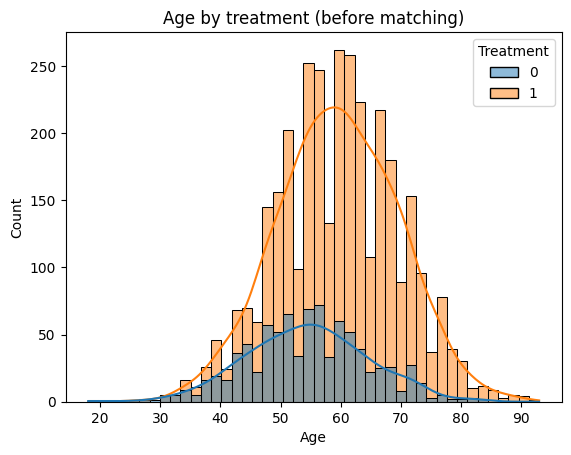

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x='Age', hue='Treatment', kde=True)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age by treatment (before matching)')
plt.show()

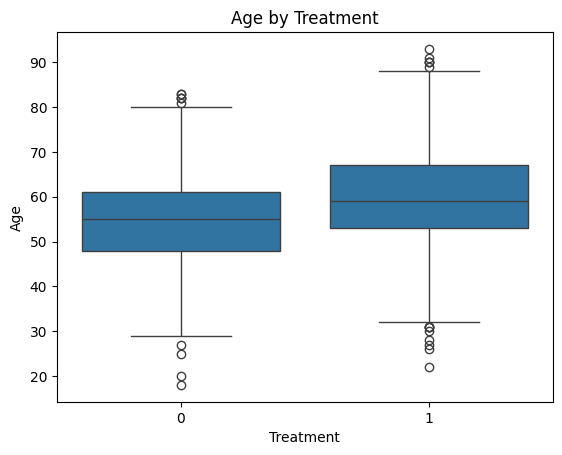

In [19]:
sns.boxplot(data=df, x='Treatment', y='Age')
plt.title('Age by Treatment')
plt.show()

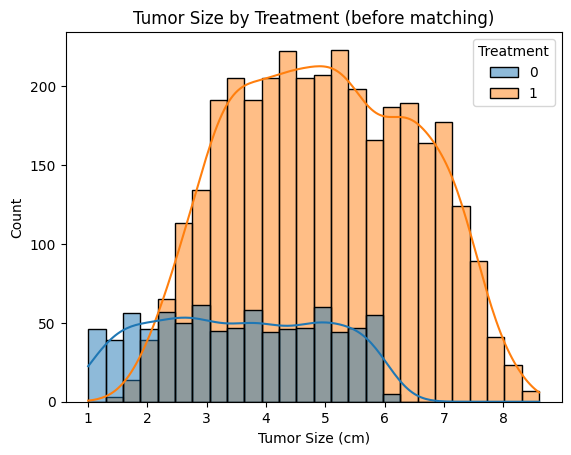

In [15]:
sns.histplot(data=df, x='Tumor Size (cm)', hue='Treatment', kde=True)
plt.title('Tumor Size by Treatment (before matching)')
plt.show()

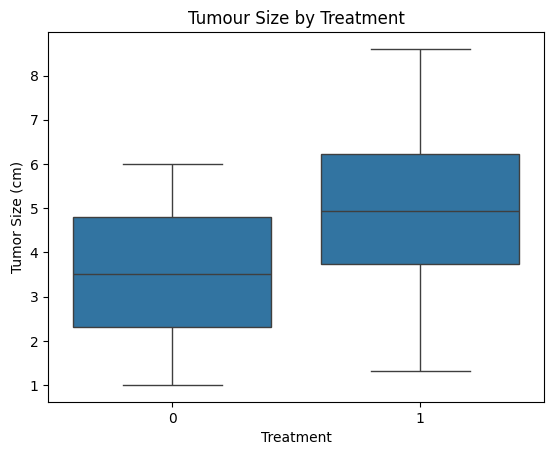

In [18]:
sns.boxplot(data=df, x='Treatment', y='Tumor Size (cm)')
plt.title('Tumour Size by Treatment')
plt.show()

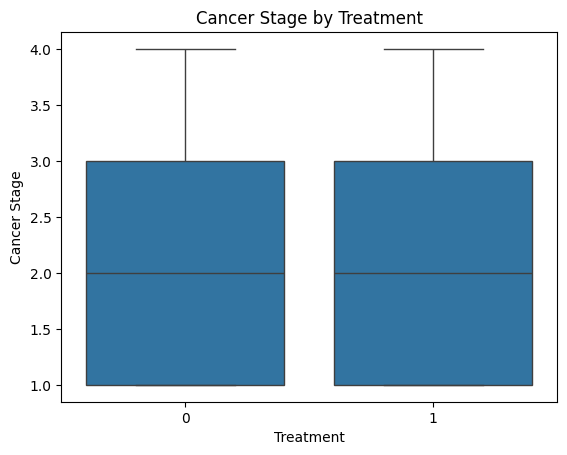

In [16]:
sns.boxplot(data=df, x='Treatment', y='Cancer Stage')
plt.title('Cancer Stage by Treatment')
plt.show()

- variables that differ the most:
  - tumour size (control around 3.5cm, treated around 5cm)
  - age (control around 54.5, treated around 59.5)
  - gender (50% control male, 80% treated male)

- these gaps could explain survival differences (large tumours and older age would suggest and are associated with worse survival rates generally) - this would mean raw comparisons of treated and control survival would be biased.






### Step 3: choose confounders by predicting treatment

- building X from baseline covariates - dropping Treatment from X (no Survival in X)
- Encoding categoricals and scaling numerics
- fitting a model that predicts Treatment from X
- using model output (coefficients) with clinical reasoning to fix the covariate set for the propensity model

In [22]:
#build X from baseline covariates only
baseline_cols = ['Age', 'Gender', 'Tumor Size (cm)', 'Cancer Stage', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection']

#drop treatment from X
X = df[baseline_cols].copy()
y_treatment = df['Treatment']


#one hot encoding
X_encoded = pd.get_dummies(X, columns=['Gender'], drop_first=True)
X_encoded.head()






,Age,Tumor Size (cm),Cancer Stage,Tobacco Use,Alcohol Consumption,HPV Infection,Gender_Male
0,64.0,1.782186,1,1,1,1,True
1,57.0,5.763047,1,1,1,0,True
2,57.0,6.672537,4,1,0,1,True
3,57.0,2.574571,1,0,0,0,True
4,77.0,5.248032,1,1,1,0,True


In [23]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

#pipeline sketch
numeric_features = ['Age', 'Tumor Size (cm)', 'Cancer Stage', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection']

categorical_features = ['Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

clf = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])


clf.fit(X, y_treatment)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Tumor Size (cm)',
                                                   'Cancer Stage',
                                                   'Tobacco Use',
                                                   'Alcohol Consumption',
                                                   'HPV Infection']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [24]:
#check encoded names
feature_names = (
    numeric_features
    + list(clf.named_steps['prep']
             .named_transformers_['cat']
             .get_feature_names_out(categorical_features))
)

print(feature_names)

['Age', 'Tumor Size (cm)', 'Cancer Stage', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection', 'Gender_Male']


In [25]:
#model output/coefficients
coefficients = clf.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

coef_df

#rank by size
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df.sort_values(by='Abs_Coefficient', ascending=False)

,Variable,Coefficient,Abs_Coefficient
6,Gender_Male,1.398775,1.398775
1,Tumor Size (cm),1.069302,1.069302
0,Age,0.470416,0.470416
2,Cancer Stage,0.051704,0.051704
5,HPV Infection,0.036076,0.036076
3,Tobacco Use,-0.026865,0.026865
4,Alcohol Consumption,-0.006939,0.006939


- the treatment prediction model shows that gender, tumour size and age are the strongest predictors of treatment assignment
- male patients with largest tumours are most likely to receive treatment which matches what the imbalance earlier implied.

- survival and post treatment variables (such as chemo and surgery) were dropped to prevent data leakage.

- the model may indicate that variables such as tobacco use and alcohol consumption have weak associations with treatment but they are still considered as potential confounders as even small effects may add up.
- the final model prioritizes age, tumour size, gender and cancer stage variables as they have stronger evidence of association.


### Step 4: Propensity scores and overlap
- fitting a model for P(Treatment = 1 | X)
- saving scores in propensity_score
- plotting score distributions for treated vs untreated and describing overlap

In [26]:
#final confounder set from Step 3
baseline_cols = ['Age', 'Gender','Tumor Size (cm)','Cancer Stage']

X = df[baseline_cols].copy()
y_treatment = df['Treatment']

#encoding categorical variables
X_encoded = pd.get_dummies(X, columns=['Gender'], drop_first=True)


In [27]:
from sklearn.linear_model import LogisticRegression

#fitting logistic propensity model
ps_model = LogisticRegression(max_iter=1000, random_state=42)
ps_model.fit(X_encoded, y_treatment)

LogisticRegression(max_iter=1000, random_state=42)

In [28]:
#saving propensity scores

df['propensity_score'] = ps_model.predict_proba(X_encoded)[:, 1]

df[['propensity_score', 'Treatment']].head()

,propensity_score,Treatment
0,0.618534,0
1,0.943716,1
2,0.972730,1
3,0.666440,1
4,0.967381,1


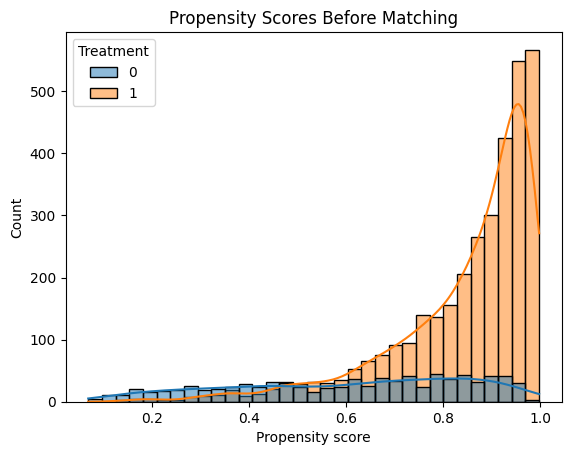

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

#overlap plot

sns.histplot(data=df, x='propensity_score', hue='Treatment', kde=True)
plt.xlabel('Propensity score')
plt.title('Propensity Scores Before Matching')
plt.show()

- overlap is weak at the extremes of the propensity score distribution - at high propensity scores (above roughly 0.9), there are mostly treated individuals, while at very low scores, there are mostly control individuals

- in regions with poor overlap, there are fewer suitable matches between treated and control patients which leads to unreliable estimates of the effects of treatments in those regions

- trimming extreme propensity scores would improve the quality of matching as comparisons are only made between patients with similar probabilities of receiving treatment

### Step 5: Propensity score matching and balance
- running 1:1 nearest-neighbour matching on the propensity score - matching treated to control
- using a caliper (max distance) - starting point at 0.2 × SD(propensity score) then picking final value
- building a matched dataset, report counts of treated and matched controls (and any dropped rows).
- showing balance after matching using plots

In [30]:
#split groups
treated = df[df['Treatment'] == 1].copy()
control = df[df['Treatment'] == 0].copy()



In [44]:
#nearest neighbour matching (1:1)
from sklearn.neighbors import NearestNeighbors
import numpy as np

#setting caliper
caliper = 0.05 * np.std(df['propensity_score'])

#fitting nearest neighbours on control group
nbrs = NearestNeighbors(n_neighbors=1).fit(control[['propensity_score']])

#finding nearest control for each treated
distances, indices = nbrs.kneighbors(treated[['propensity_score']])

In [45]:
#apply caliper

mask = distances.flatten() <= caliper

matched_treated = treated[mask]
matched_control = control.iloc[indices.flatten()[mask]]

In [46]:
#combine matched dataset

matched_df = pd.concat([matched_treated, matched_control], axis=0)

print("Original treated:", len(treated))
print("Matched treated:", len(matched_treated))
print("Matched control:", len(matched_control))

Original treated: 3382
Matched treated: 3357
Matched control: 3357


In [41]:

#balance before matching
print("Before matching (Age):")
print(df.groupby('Treatment')['Age'].mean())

#balance after matching
print("\nAfter matching (Age):")
print(matched_df.groupby('Treatment')['Age'].mean())

Before matching (Age):
Treatment
0    54.540445
1    59.476345
Name: Age, dtype: float64

After matching (Age):
Treatment
0    61.500591
1    59.476345
Name: Age, dtype: float64


In [42]:
print("After matching (Tumor Size):")
print(matched_df.groupby('Treatment')['Tumor Size (cm)'].mean())

After matching (Tumor Size):
Treatment
0    4.782458
1    4.978171
Name: Tumor Size (cm), dtype: float64


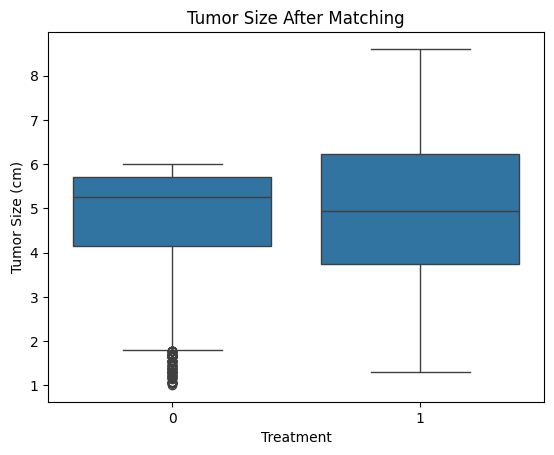

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=matched_df, x='Treatment', y='Tumor Size (cm)')
plt.title('Tumor Size After Matching')
plt.show()

- after matching using the 0.2 caliper, balance improved for tumour size, where the difference between treated and control groups became much smaller (from over 1 to 0.2)
- difference in age was also reduced, it was not completely eliminated and slightly reversed, indicating that matching improved but did not fully resolve imbalance

- the sample size remained unchanged after matching which suggests that all treated observations were successfully matched, implying the caliper was wide, allowing more matches but maybe reducing match quality.

- reducing the caliper from 0.2 to 0.1 did not change the number of matched observations, indicating that the caliper was still too open, so age balance did not improve much.
- tightening even furtehr to 0.05 reduced the sample size slightly, suggesting some poor matches were removed (25 drppped)
- this improves the matches quality while still retaining most observations
- tumour size balance improved and so did age but age is still not similarly balanced (around 2 years difference between control).

- the caliper of 0.05 was chosen as it provided good balance between match quality and sample size, larger calipers retained all observations but allowed poorer matches - this tighter caliper removed unsuitable matches without lots of data loss




### Step 6: ATE before and after matching
- before matching, calculating mean Survival for Treatment == 1 minus mean for Treatment == 0 on the full data (difference is a crude ATE estimate on the observed scale)
- After matching, same calculation on  matched dataframe
- Show in a bar chart
- chi-square on Treatment × Survival before and after matching - Reporting both p-values showing association, not proving causation.

In [47]:
#mean and ATE before
m_before = df.groupby('Treatment')['Survival'].mean()

ate_before = m_before.loc[1] - m_before.loc[0]

print("Mean survival (before matching):")
print(m_before)

print("\nATE before matching:", ate_before)

Mean survival (before matching):
Treatment
0    0.524033
1    0.696038
Name: Survival, dtype: float64

ATE before matching: 0.1720050221051661


In [48]:
#mean and ATE after
m_after = matched_df.groupby('Treatment')['Survival'].mean()

ate_after = m_after.loc[1] - m_after.loc[0]

print("Mean survival (after matching):")
print(m_after)

print("\nATE after matching:", ate_after)

Mean survival (after matching):
Treatment
0    0.571046
1    0.695562
Name: Survival, dtype: float64

ATE after matching: 0.12451593684837647


In [49]:
from scipy.stats import chi2_contingency

#chi squared calc

#before matching
tab_before = pd.crosstab(df['Treatment'], df['Survival'])
chi2_b, p_b, _, _ = chi2_contingency(tab_before)

#after matching
tab_after = pd.crosstab(matched_df['Treatment'], matched_df['Survival'])
chi2_a, p_a, _, _ = chi2_contingency(tab_after)

print("p-value before matching:", p_b)
print("p-value after matching:", p_a)

p-value before matching: 3.525518629538561e-21
p-value after matching: 4.5404871323660823e-26


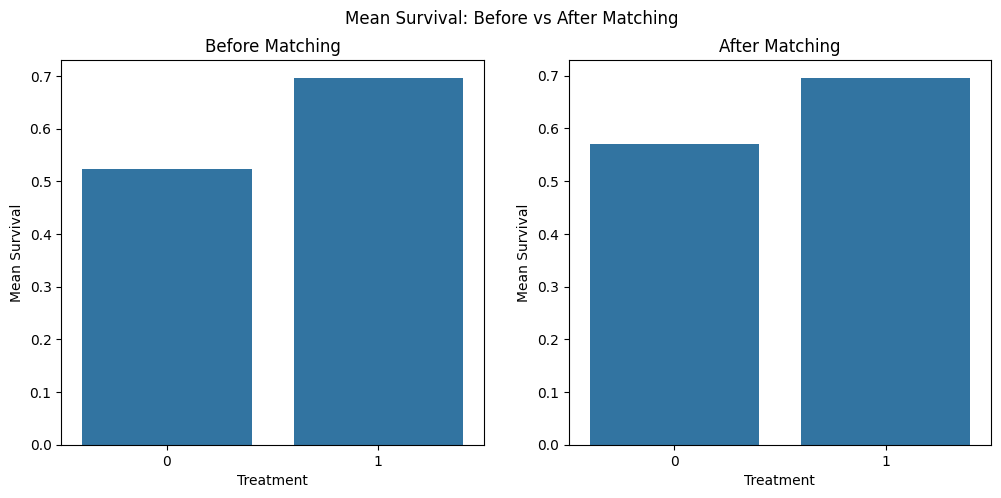

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

#bar charts of mean survival
before_means = df.groupby('Treatment')['Survival'].mean().reset_index()
after_means = matched_df.groupby('Treatment')['Survival'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


#before matching
sns.barplot(data=before_means, x='Treatment', y='Survival', ax=axes[0])
axes[0].set_title('Before Matching')
axes[0].set_ylabel('Mean Survival')

#after matching
sns.barplot(data=after_means, x='Treatment', y='Survival', ax=axes[1])
axes[1].set_title('After Matching')
axes[1].set_ylabel('Mean Survival')

plt.suptitle('Mean Survival: Before vs After Matching')
plt.show()

- ATE decreased from 0.172 to 0.125 after matching, suggesting that the original raw estimate was biased higher due to confounding factors
- matching reduced imbalance between the control and treated groups and provided an estimate of the effect of treatment that was more reliable

- both p values before and after matching are small and suggest correlation/association between treatment and survival but this does not imply causation
- P values may mislead as there is a large sample size so even small differences are significant so P values are not informative about the true causal effect.

- matching reduced the estimated treatment effect by making groups more easy to compare and suggested that the original difference in survival was due to a confounding factor instead of the true causal effect.






### Step 7: Verification and documentation

1.  final confounders

- before selecting the final confounding variables, i examined baseline differences between treated and non-treated groups.
- age, gender and tumour size showed the most imbalance between the 2 groups as discussed above.
- after fitting a LR model to predict the treatment assignment, the model coefficients were checked to see which variables/factors had the greatest associations with treatment
- gender, age and tumour size showed the greatest assosciations with treatment with cancer stage showing small association and then factors like hpv infection, smoking and alcohol consumption showing very small associations.
- I also thought cancer stage would be causually important even though its coefficient wasnt as large as the other three as generally it is a known idea that further developed stages affect chances of survival in different ways to less developed

- For these reasons the final set included:
  - gender
  - tumour size
  - age
  - cancer stage

2. propensity score model + overlap

- using an LR model to predict propensity scores, the overlap showed that patients who recieved treatment usually had propensity scores between 0.7 and 1 whereas control patients had much lower, more spread propensity scores
- this meant that there was very minimal overlap - esecially at the start and end of the plot

3. matching direction, caliper, final Ns

- 1 to 1 nearesr neighbour matching was used from treated to control
- the caliper used was 0.05 x SD
- the final sample sizes were:
  - original treated: 3382
  - matched treated: 3357
  - matched control: 3357
- reducing the caliper down from 0.2 removed some poor matches which improved match quality but the value wasnt reduced further than 0.05 as this would mean more observations would be dropped

- after matching, balance improved in the confounder groups especially in tumour size, but age improved only slightly.

4. ATE + chi-squared
- before matching: ATE had the value of 0.172
- after matching: ATE had the value of 0.125
- this is a decrease of more than 25% which suggests that the original estimate was biased upwards becaise of to confounding and matching produced a more relaible estimate value

- p values both before and after matching were very small suggesting that there is a strong association between treatment and survival regardless of the case but this does not indicase causation.

5. limitations

- there could be confounders that I did not include that could have effected the results more OR there could be confounders that werent included in the dataset at all that could have effected results
- there may also be another model that performs better than LR for propensity score calculations/estimations
- there was also not much overlap so limited matching
- some factors (like age) may still be slightly imbalanced






## Summary and Reflection (PBL9)

1. Data quality and cohort
- This data had already been preprocessed so the problem wasnt any missing values and I only had to encode variables correctly, but the imbalance in the group sizes for treatment (more treated than untreated).
- The exclusions came from the seelction of the final variables to be used in the treatment model.
- Aince Survivial is the dependent outcome, this was excluded along with post-treatment variables (or variables that ARE the treatment and so would not be confounding) such as Chemotherapy, Targeted therapy, Radiation and Surgery.
- The caliper was also tightened slightly to remove 25 treated patients that had no similar control patients to match to so the matched dataset ended up with 3357 patients instead of the original 3382.
- The data was deemed fit for use after analysing the initial set where column names and information was checked for, including null values (none).

2. Confounding and variables
- Age, Gender, Tumor Size, and Cancer Stage were all kept as these are clinically plausible confounders because treatment decisions in oral cancer are likely to depend on patient characteristics and disease severity - also older patients, patients with larger tumours, and patients with more advanced stage disease may be treated differently, and these factors could also survival.
- the treatment model showed the strongest associations with age, tumour size and gender, matching earlier observed imabalance.
- cancer stage showed a lower association but was larger than other observed factors and followed my justification so was included
- some cofounders that were missing could be social background, economic background, more detail on tumours such as specific area maybe

3. Matching
- 1:1 nearest neighbour matching was used to match treated to control patients
- I started with the value of 0.2 for the caliper and then halved the value until I saw a change with fewer matches. This value ended up being 0.05 and it was the first value that removed values that didnt have good matches without removing many more observations.
- Before matching, tumour size had the largest dofferences between the groups, with people with larger tumours being selected for treatment more often.
- After matching, this tumour size was more balanced as well as age being slightly more balanced.
- A larger caliper kept more matched pairs but some of these clearly were not very similar looking at the plotted charts. The smaller caliper dropped weak matched so increased the quality of matched but of course reduced sample size.

4. Treatment effects
- ATE decreased from 0.172 to 0.125
- this means that the confoudning gave an upwards bias to the original crude estimate
- chi squared values remained small both before and after matching implying association between survival and treatment
- the most important numbers were the ATE values, the mean survival and imbalance in groups as they showed how confoudnign would effect the estimate of treatment and if matching even made the groups comparable
- to a clinicial, I would explain that before the adjustments, treated patients had a higher advantage of survival, partly explained by the initial imbalance between groups. After matching, treatment still was beneficial but the estimated effect decreased and therefore there are multiple confounding factors that effect survival too.


5. Limits and next steps
- One limit is remaining imabalance after matching and limited overlap between the two groups
- Another is unmeasured confounding not being considered as well as important confounders not being included as these could also bias the treatment outcome
- An LR model may also not be as good at predicting propensity score as other models
- In a follw up, maybe different models of propensity could be tested.





